# Tutorial03: Classifier Performance Measures
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> H. B. Prosper<br>


## Introduction

In the notebook `tutorial02`, we built a simple **discriminant** $D(x)$ to classify the points $x \in \mathbb{R}^2$ sampled from two known Gaussians. In motebook `tutorial02_metrics`, we evaluated the discriminant using the **Receiver Operating Characteristic** (ROC) curve and the **Area Under the (ROC) Curve** (AUC). In this notebook, we introduce a few other useful measures to characterize the performance of a classifier.

In [1]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt
%matplotlib inline

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

import importlib
import joblib

import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": True, # turn off if the system can'r find late
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "font.size": FONTSIZE
})

# set a seed to ensure reproducibility
seed = 128
rnd  = np.random.RandomState(seed)

## Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

BASE = '../../Lab02' # base location of model

# file containing parameters of trained model
params_file = f'{BASE:s}/code/gauss2d_params.pth' 

Available device: cpu 


## Exact density

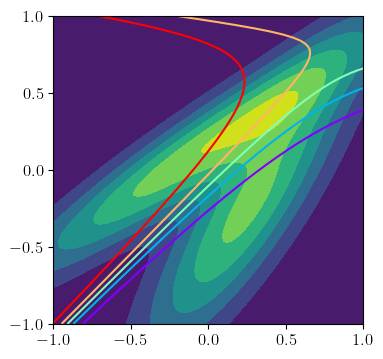

In [3]:
# update paths searched by Python to find packages/modules

sys.path.append(f'{BASE:s}/code')

from exactdensity import ExactDensity

fexact = ExactDensity()
fexact.plot()

## Import trained model

In [4]:
import gauss2d
importlib.reload(gauss2d)

model = gauss2d.model
model.load(params_file)

print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=15, bias=True)
    (1): SiLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): SiLU()
    (4): Linear(in_features=15, out_features=15, bias=True)
    (5): SiLU()
    (6): Linear(in_features=15, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
number of parameters 541


## Load test data

In [5]:
test_data_file = f'{BASE:s}/data/test_data.pth' 

test_data = joblib.load(test_data_file)

test_loader = dat.DataLoader(test_data, 
                             batch_size=len(test_data))
print(len(test_data))

print(test_data[:5])

DataLoader
  maxiter:               1
  batch_size:        15000
  shuffle_step:          1

15000
(tensor([[ 0.0556, -0.2532],
        [ 0.5827,  0.6638],
        [-0.7085, -0.2759],
        [ 0.2132, -0.2555],
        [-0.2529, -0.7615]]), tensor([[1.],
        [1.],
        [0.],
        [1.],
        [1.]]))


## Compute approximate discriminant values

In [6]:
test_loader.reset()
x, y = next(test_loader)
print('x.shape', x.shape)
print('y.shape', y.shape)

y = y.squeeze()
print('y.shape', y.shape)

Dapprox = model(x).squeeze().detach().cpu().numpy()

print(Dapprox.shape)

x.shape torch.Size([15000, 2])
y.shape torch.Size([15000, 1])
y.shape torch.Size([15000])
(15000,)


## Compute exact discriminant values

In [7]:
fexact = ExactDensity()

x1 = x[:, 0] # extract all rows (:) of column 0
x2 = x[:, 1] # extract all rows (:) of column 1

Dexact = fexact.prob(x1, x2)

Dexact.shape

(15000,)

## Divide data into "positives" and "negatives"
"positive" objects are defined by $y > t$, while "negative" objects are defined by $y \le t$, with $t = 0.5$.

In [8]:
t = 0.5

positives = Dapprox[y > t]

negatives = Dapprox[y <= t]

len(Dapprox), len(positives), len(negatives)

(15000, 7510, 7490)


\begin{align}
    \text{TP} & : \sum_{i \, |\, y_i = 1} \mathbb{I}[D(x_i) > t], \\
    \text{FN} & : \sum_{i \, | \, y_i = 1} \mathbb{I}[D(x_i) \leq t], \\
    \text{FP} & : \sum_{i \, | \, y_i = 0} \mathbb{I}[D(x_i) > t], \\
    \text{TN} & : \sum_{i \, | \, y_i = 0} \mathbb{I}[D(x_i) \leq t] .
\end{align}

In [9]:
TP = np.sum(positives >  t)
FN = np.sum(positives <= t)
FP = np.sum(negatives >  t)
TN = np.sum(negatives <= t)

TP, FN, FP, TN, TP+FN+FP+TN

(np.int64(6158),
 np.int64(1352),
 np.int64(508),
 np.int64(6982),
 np.int64(15000))

## Plot distributions of discriminant values
What we are doing here is approximating the densities

\begin{align}
    p(D | 0) & = \int_{\mathbb{R}^2} \delta(D - f(x)) \, p(x | 0) \, dx, \\
    p(D | 1) & = \int_{\mathbb{R}^2} \delta(D - f(x)) \, p(x | 1) \, dx,
\end{align}

using histograms.

D_dist_1_t0.5.png


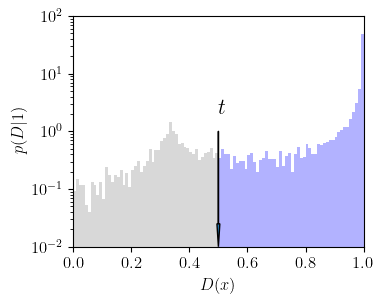

D_dist_0_t0.5.png


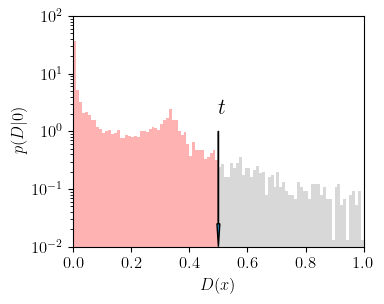

In [10]:
def plot_distribution(D, y, which=1, t=0.5,
                      nbins=100, ymin=1.e-2, ymax=1e2,
                      ftsize=FONTSIZE, 
                      fgsize=(4, 3.2)):

    # select objects (points)
    if which == 1:
        d = D[y > 0.5] 
        kolor = 'blue'
        leftlabel =  f'FN / $y = {which:d}$'
        rightlabel = f'TP / $y = {which:d}$'

        kstart = 0
        kend = int(nbins * t + 0.5)
    else: 
        d = D[y < 0.5]
        kolor = 'red'
        leftlabel =  f'TN / $y = {which:d}$'
        rightlabel = f'FP / $y = {which:d}$'
        kstart = int(nbins * t + 0.5)
        kend = nbins
        
    gfile = f'D_dist_{which:d}_t{t:3.1f}.png'
    
    # set size of figure
    fig = plt.figure(figsize=fgsize)
    
    plt.xlim(0, 1)
    plt.xlabel('$D(x)$')
    
    plt.ylim(ymin, ymax)
    plt.ylabel(f'$p(D|{which:d})$')
    plt.yscale('log') 
    
    _,_, patches = plt.hist(d, 
             bins=nbins, 
             color=kolor,
             alpha=0.3,
             range=(0, 1), 
             density=True)
    

    for i in range(kstart, kend):
        patches[i].set_facecolor('grey')

    plt.text(t, 2.0, '$t$', fontsize=16)
    plt.arrow(t, 1.0, 0, -1.0+ymin, head_width=0.01, length_includes_head=True)
    fig.tight_layout()
    
    print(gfile)
    plt.savefig(gfile)
    plt.show()
    
plot_distribution(Dapprox, y, which=1, t=t)
plot_distribution(Dapprox, y, which=0, t=t)

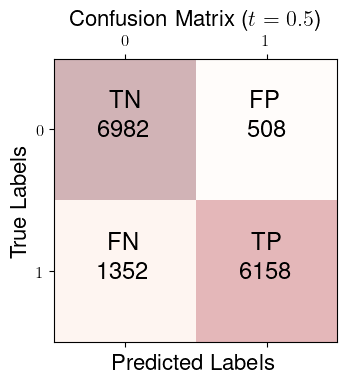

In [11]:
def plot_confusion_matrix(D, y, t=0.5, gfile='confusion_matrix.png'):
    from sklearn.metrics import confusion_matrix

    y_pred = D > t
    
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_true=y, y_pred=y_pred)

    # Print the confusion matrix using Matplotlib
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.matshow(conf_matrix, cmap=plt.cm.Reds, alpha=0.3)

    label = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i,s=conf_matrix[i, j], 
                    va='center', ha='center', size='x-large')
            ax.text(x=j, y=i-0.2, s=label[i][j], 
                    va='center', ha='center', size='x-large')
 
    plt.xlabel('Predicted Labels', fontsize=16)
    plt.ylabel('True Labels', fontsize=16)
    plt.title(f'Confusion Matrix ($t = {t:3.1f}$)', fontsize=16)
    fig.tight_layout()
    plt.savefig(gfile)
    plt.show()
    
plot_confusion_matrix(Dapprox, y, t=t, gfile=f'confusion_matrix_t{t:.1}.png')